# Projekt 1

## Filip Nocoń
---

### Inicjalizacja potrzebnych bibliotek

In [1]:
# Tutaj należy zaimportować potrzebne biblioteki
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
%matplotlib inline

### 1. Wczytanie plików z danymi Boston - Przejazdu samochodu - Mobile

In [2]:
# Wczytanie i wyświetlanie  - Boston
df_boston = pd.read_csv("data/Boston.csv")   
df_boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CAT. MEDV,Unnamed: 15,Unnamed: 16
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0,NaN,NaN
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0,NaN,NaN
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1,NaN,NaN
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1,NaN,NaN
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1,NaN,NaN


In [3]:
# Wczytanie i wyświetlanie  - IE-2009-11-05_var1-9
df_car = pd.read_csv("data/IE-2009-11-05_var1-9.csv", sep=";")
df_car.head()

,Data i Godzina,Godzina,Wydatek paliwa,Wskazania wagi,Temperatura spalin w komorze 1,Temperatura spalin w komorze 2,Temperatura spalin w stozku 1,Temperatura spalin w stozku 2,Przeplyw O2 w czynniku pierwotnym,Przeplyw O2 w czynniku wtornym,...,Stezenie CO 2,Stezenie NO 2,Stezenie SO2 2,Stezenie O2 3,Stezenie CO 3,Stezenie NO 3,Stezenie CO2 1,Stezenie CO2 2,Stezenie CO 4,Stezenie O2 6
0,05.11.2009 13:50,13:50:00.410,57.048,31.1656,1223.280228,1160.828019,1070.801272,1017.985868,#NV,0.695600983,...,20.2337373,818.6265454,251.308009,7.561587,23.10697362,875.671416,15.337520,12.576143,#NV,3.814786
1,05.11.2009 13:50,13:50:01.420,60,31.1000,1224.714752,1174.034549,1068.726453,1017.406176,#NV,0.196139656,...,20.02647147,818.2375785,251.096692,7.534275,23.44033122,875.730984,15.319597,12.809888,#NV,3.849639
2,05.11.2009 13:50,13:50:02.430,61.2,31.0800,1223.539616,1179.053935,1070.209141,1020.058106,0.040231736,#NV,...,20.4769522,818.5801655,251.591876,7.439902,23.29159901,875.071272,15.305435,13.012069,#NV,3.885944
3,05.11.2009 13:50,13:50:03.440,59.28,31.0960,1222.303174,1159.081458,1069.998256,1019.636753,#NV,#NV,...,20.86526714,818.5594901,250.739437,7.331005,23.39527383,874.236621,15.288799,13.069028,#NV,3.923073
4,05.11.2009 13:50,13:50:04.450,58.8,31.0748,1219.333417,1186.023439,1074.788007,1016.691744,0.013619532,#NV,...,20.42898908,818.2707801,250.632986,7.224972,23.64481241,873.229843,15.274562,13.078601,#NV,3.948888


In [4]:
# Wczytanie i wyświetlanie  - mobile
df_mobile = pd.read_csv("data/mobile.csv", sep=",")
df_mobile.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


### 2. Ocena kompletności danych

In [5]:
# Wybranie interesujących mnie kolumn - Boston
df_boston_plot = df_boston[["MEDV", "RM", "CRIM"]].dropna()
# sortowanie po cenie
df_boston_plot = df_boston_plot.sort_values(by="MEDV")
print(df_boston_plot.head())


     MEDV     RM      CRIM
398   5.0  5.453  38.35180
405   5.0  5.683  67.92080
400   5.6  5.987  25.04610
399   6.3  5.852   9.91655
414   7.0  4.519  45.74610


In [6]:
# Wybranie interesujących mnie kolumn - IE-2009-11-05_var1-9
# wybranie pierwszych 200 pomiarów
df_car_plot = df_car.head(200)[["Godzina", "Wydatek paliwa", "Wskazania wagi"]].dropna()
# konwersja godziny na datetime
df_car_plot["Godzina"] = pd.to_datetime(df_car_plot["Godzina"], format="%H:%M:%S.%f")
# uśrednienie Wydatek paliwa co 10 pomiarów ( inaczej jest brzydki wykres liniowy )
df_car_plot["Wydatek paliwa uśrednione"] = df_car_plot["Wydatek paliwa"].rolling(10).mean()

# usunięcie wierszy z NaN powstałych przy średniej
df_car_plot = df_car_plot.dropna().reset_index(drop=True)

print(df_car_plot.head())

                  Godzina Wydatek paliwa  Wskazania wagi  \
0 1900-01-01 13:50:09.500         58.656         31.0052   
1 1900-01-01 13:50:10.510             60         30.9664   
2 1900-01-01 13:50:11.520         60.612         30.9498   
3 1900-01-01 13:50:12.530         60.384         30.9400   
4 1900-01-01 13:50:13.540         58.644         30.9374   

   Wydatek paliwa uśrednione  
0                    58.4136  
1                    58.7088  
2                    58.7700  
3                    58.6884  
4                    58.6248  


In [7]:
# Wczytanie i wyświetlanie  - mobile
df_mobile_plot = df_mobile[["battery_power", "ram", "wifi","price_range"]].dropna()
df_mobile_plot = df_mobile_plot.sort_values(by="ram")
df_mobile_plot.head()


,battery_power,ram,wifi,price_range
1745,926,256,1,0
1389,1801,258,0,0
467,1433,258,1,0
1230,697,259,1,0
1224,1515,262,0,0


### 3. Eksportowanie danych do innych formatów

In [8]:
df_boston_plot.to_csv("df_boston_plot.csv", index=False)

In [9]:
df_car_plot.to_json("df_car_plot.json", orient="records")

In [10]:
df_mobile_plot.to_html("df_mobile_plot.html")

### 4. Wykresy liniowe (wybranych kolumn)

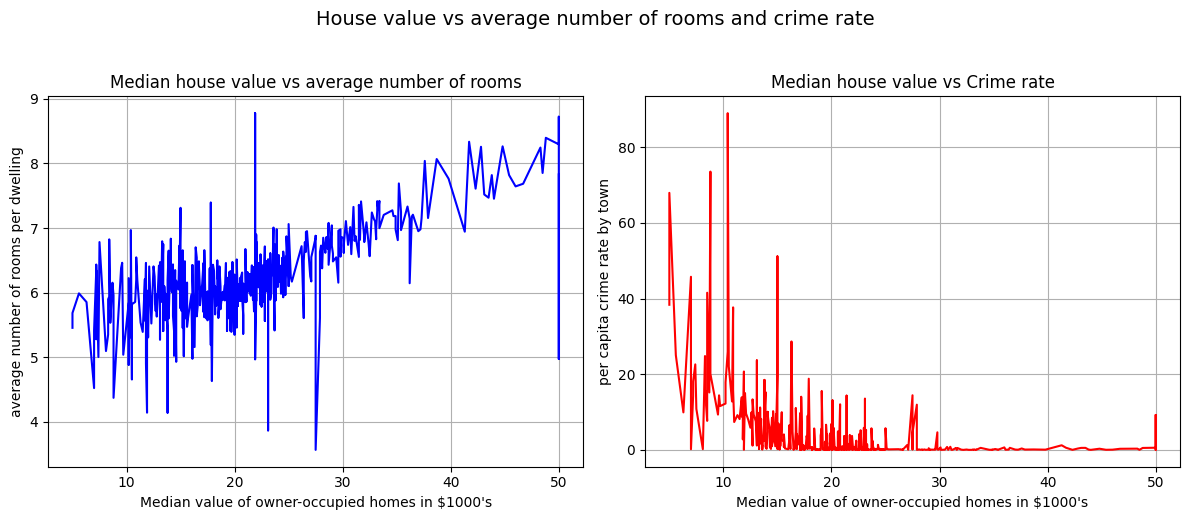

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("House value vs average number of rooms and crime rate", fontsize=14, y=1.03)

# MEDV vs RM
axs[0].plot(df_boston_plot["MEDV"], df_boston_plot["RM"], color='blue')
axs[0].set_ylabel("average number of rooms per dwelling")
axs[0].set_xlabel("Median value of owner-occupied homes in $1000's")
axs[0].set_title("Median house value vs average number of rooms")
axs[0].grid(True)

# MEDV vs CRIM
axs[1].plot(df_boston_plot["MEDV"], df_boston_plot["CRIM"], color='red')
axs[1].set_ylabel("per capita crime rate by town")
axs[1].set_xlabel("Median value of owner-occupied homes in $1000's")
axs[1].set_title("Median house value vs Crime rate")
axs[1].grid(True)

plt.tight_layout()
plt.show()

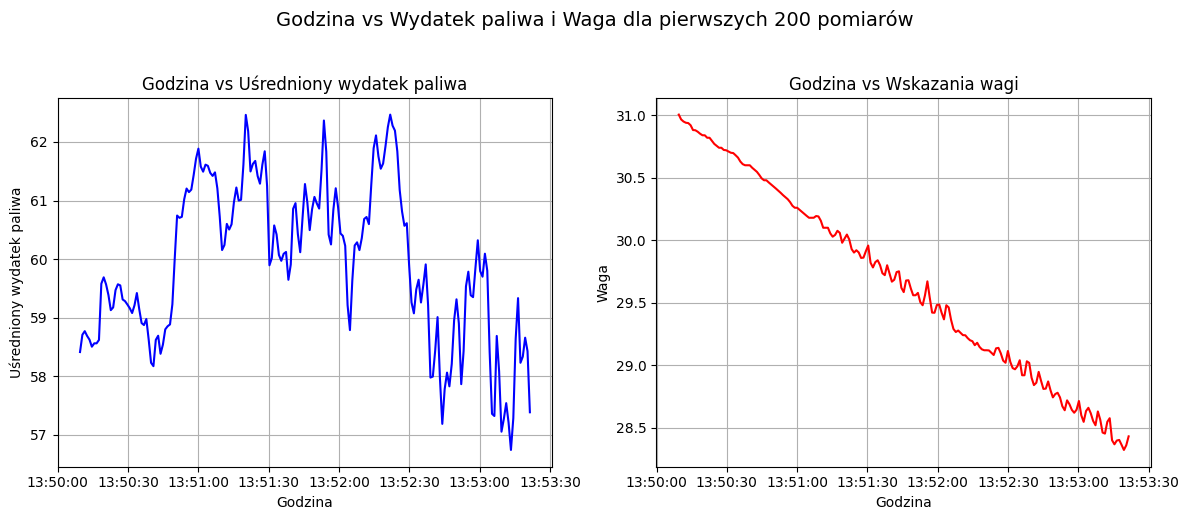

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Godzina vs Wydatek paliwa i Waga dla pierwszych 200 pomiarów", fontsize=14, y=1.03)

# paliwo
axs[0].plot(df_car_plot["Godzina"], df_car_plot["Wydatek paliwa uśrednione"], color='blue')
axs[0].set_xlabel("Godzina")
axs[0].set_ylabel("Uśredniony wydatek paliwa")
axs[0].set_title("Godzina vs Uśredniony wydatek paliwa")
axs[0].grid(True)

# waga
axs[1].plot(df_car_plot["Godzina"], df_car_plot["Wskazania wagi"], color='red')
axs[1].set_xlabel("Godzina")
axs[1].set_ylabel("Waga")
axs[1].set_title("Godzina vs Wskazania wagi")
axs[1].grid(True)

plt.tight_layout()
plt.show()


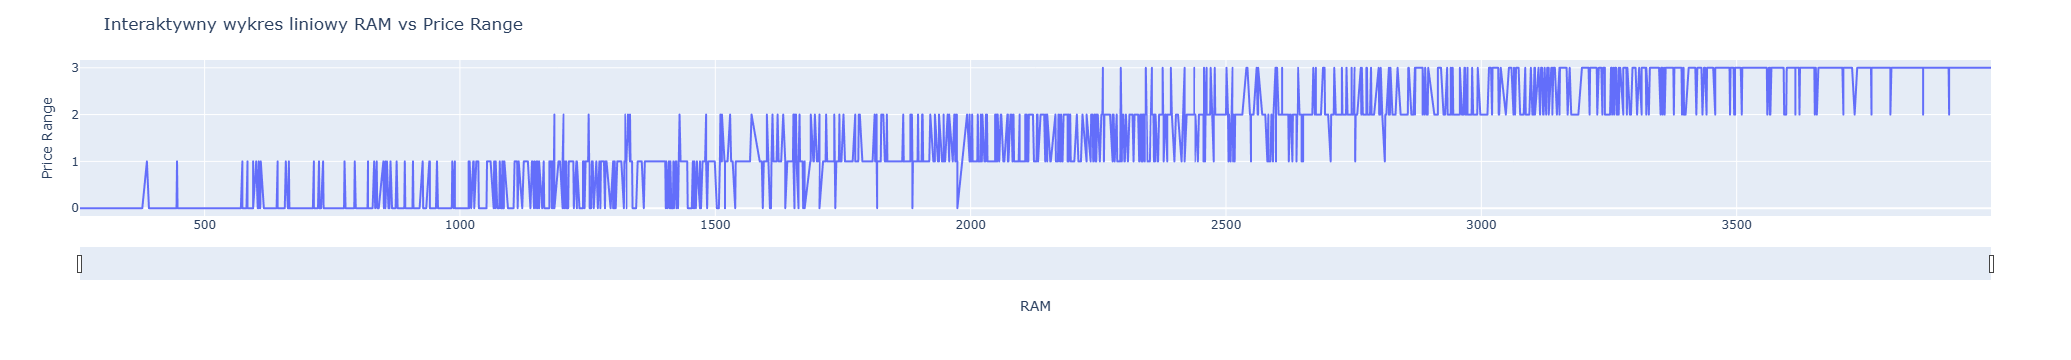

In [13]:
fig = px.line(
    df_mobile_plot,
    x="ram",
    y="price_range",
    hover_data=["battery_power", "ram", "wifi"]
)
fig.update_xaxes(rangeslider_visible=True)
fig.update_layout(
    title="Interaktywny wykres liniowy RAM vs Price Range",
    xaxis_title="RAM",
    yaxis_title="Price Range"
)

fig.show()


### Wnioski

Korzystanie z takiego serwisu internetowego jest bardzo wygodne — nie trzeba samodzielnie konfigurować środowiska, co znacząco przyspiesza pracę i pozwala na pracę w dowolnym miejscu.

Obróbkę danych trzeba dostosować do informacji, które nas interesują. Niby to nic zaskakującego, ale do tej pory nie poświęcałem temu większej uwagi. Na tym etapie należy bardzo uważać na to, jakie operacje wykonuje się na danych — nieuważna modyfikacja może prowadzić do bezsensownych rezultatów na późniejszych etapach.

Do eksportu nie mam komentarza.

Najciekawszą obserwacją jest to, że jeśli poświęcimy czas na odpowiednie przygotowanie danych, to tworzenie estetycznych wykresów nie sprawia większych problemów. Trzeba tylko zastanowić się, co chcemy osiągnąć, i przyjąć odpowiednią metodę. Najwięcej trudności miałem z datasetem dotyczącym samochodów. Nie wiem, czy podejście, które zastosowałem, jest idealne, ale wykresy wyglądają dobrze, więc na pierwszy rzut oka nie widzę problemów.

Moim sposobem pracy było najpierw próbowanie samodzielnego rozwiązania — jeśli nie szło, sięgałem do dokumentacji, próbowałem ponownie, a w ostateczności rozwiązywałem problem z pomocą czatu.

---

### Dokumentacja
    https://chatgpt.com
    https://pandas.pydata.org/docs/getting_started/index.html
    https://www.kaggle.com/datasets/avish5787/boston-data-set    <--- Opis Dataset boston
    https://plotly.com/python/plotly-express/
    https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html

---

In [14]:
# Eksportowanie bieżacego notatnika do pdf.

%run ./data/notebook_export
export_notebook_to_pdf("Projekt1_Nocoń_Filip.ipynb")

Export 'Projekt1_Nocoń_Filip.ipynb': OK.


<Figure size 640x480 with 0 Axes>

**PDF wygenerowano:** Saturday, 15 November 2025 11:53:33